# Portfolio problem

In [9]:
import math
from pathlib import Path
import cvxpy as cp
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.dataset import get_portfolio_returns_df, get_num_time_windows, portfolio_dataset
from mis_dro.experiments import ExperimentName
from mis_dro.constants import IN_SAMPLE_TIME_WINDOW, OUT_OF_SAMPLE_TIME_WINDOW
from mis_dro.plot import *
from mis_dro.portfolio import portfolio_objective_cvxpy
from mis_dro.preprocessing import normalise_by_dimension
from mis_dro.results import preprocess_results_df, is_maximise_pareto_front, is_minimise_pareto_front, get_agg_df, get_result_df_list, convert_str_to_float_list

# from matplotlib import rc
# rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], "size":14})
# rc('text', usetex=True)


In [10]:
# mmc2_dir = Path("/", "Users", "patrick", "Datasets", "misdro", "mmc2")
mmc2_dir = Path("/dcs/pg20/u1508153/datasets/misdro/mmc2")
# assert mmc2_dir.exists()
dgp = "DowJones"
returns_df = get_portfolio_returns_df(mmc2_dir, dgp)
index_returns_df = pd.read_excel(mmc2_dir / "Datasets" / dgp / f"{dgp}.xlsx", sheet_name="Index_Returns", header=None)

In [11]:
experiment_name = ExperimentName.kl_portfolio
kl_experiment_dir = Path("/dcs/large/u1508153/misdro/2025_01_21_paper_bas_experiments/kl_portfolio")
# kl_experiment_dir = Path(f"/Users/patrick/experiments/misdro/2025_01_21_paper_bas_experiments/{experiment_name.value}")
assert kl_experiment_dir.exists()
kl_results_df = pd.read_csv(kl_experiment_dir / "results.csv", index_col=["uuid", "replication"])

# mmd_experiment_dir = Path("/dcs/large/u1508153/misdro/mmd_portfolio_debug/2025_01_17_normalise")
# experiment_dir = Path(f"/Users/patrick/experiments/misdro/{experiment_name.value}")
# assert mmd_experiment_dir.exists()
# mmd_results_df = pd.read_csv(mmd_experiment_dir / "results.csv", index_col=["uuid", "replication"])

all_results_df = kl_results_df.loc[kl_results_df["algorithm"].isin(["kl_dro_bas", "kl_pp", "kl_bdro"])]
# all_results_df = pd.concat([kl_results_df, mmd_results_df])

all_results_df["algorithm"].unique()

array(['kl_dro_bas', 'kl_bdro', 'kl_pp'], dtype=object)

In [12]:
# NOTE filter by DGP
filter_dgp = "DowJones"
dataset = "portfolio"
results_df = preprocess_results_df(all_results_df, filter_dgp, dataset=dataset)

# NOTE filter out when log_partition_constant G is less than epsilon
# results_df = results_df.loc[results_df["log_partition_constant"] < results_df["epsilon"]]

# NOTE we always want the same number of test observations and replications
assert np.isclose(results_df["num_test_observations"].var(), 0)
num_test_observations = results_df["num_test_observations"].unique()[0]
assert np.isclose(results_df["num_replications"].var(), 0)
num_replications = results_df["num_replications"].unique()[0]

# NOTE if you are running PP with multiple num_likelihood_samples then you will need the below line
results_df = results_df.loc[((results_df["algorithm"] == "kl_pp") & (results_df["num_likelihood_samples"] == 3600)) | (results_df["algorithm"] != "kl_pp")]

In [13]:
cv_kl_portfolio_dir = Path("/dcs/large/u1508153/misdro/cv_kl_portfolio")
cv_kl_portfolio_df = pd.read_csv(cv_kl_portfolio_dir / "results.csv", index_col=["uuid", "replication"])
cv_df = cv_kl_portfolio_df.loc[cv_kl_portfolio_df["use_cv_epsilon"]]
cv_df = preprocess_results_df(cv_df, dgp, dataset="portfolio")
cv_agg_df = get_agg_df(cv_df, ["algorithm"])
cv_agg_df


/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/results.py:63: FutureWarning: The provided callable <function mean at 0x7f434405e0c0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/results.py:63: FutureWarning: The provided callable <function std at 0x7f434405e200> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(


,out_of_sample_mean,out_of_sample_var,sum_of_in_group_var,var_of_in_group_mean,mean_solve_time,std_solve_time,mean_sample_time,std_sample_time
algorithm,,,,,,,,
kl_bdro,0.005548,0.001780,0.001650,0.000130,0.099335,0.000747,0.001957,0.000101
kl_dro_bas,0.005658,0.001808,0.001676,0.000132,0.008504,0.001483,0.000263,0.000047
kl_pp,0.003395,0.001118,0.001059,0.000059,0.200572,0.018236,0.001360,0.000073


In [14]:
agg_df = get_agg_df(results_df, ["algorithm", "epsilon", "inference"])


/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/results.py:63: FutureWarning: The provided callable <function mean at 0x7f434405e0c0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/results.py:63: FutureWarning: The provided callable <function std at 0x7f434405e200> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(


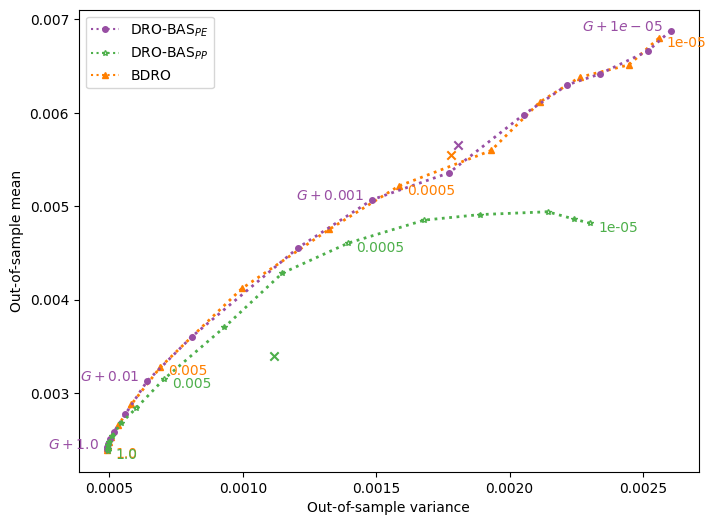

In [15]:
fig, ax = plt.subplots(figsize=(8,6))
df = agg_df
df.loc[:, "is_pareto_front"] = is_maximise_pareto_front(df["out_of_sample_var"].values, df["out_of_sample_mean"].values)
for (algorithm, inference), group_df in df.groupby(["algorithm", "inference"]):
    if algorithm == "kl_dro_bas":
        local_log_partition_constant = True
        offset=0.00003
        special_epsilons = [0.00001, 0.001, 0.01, 1.0]
    else:
        local_log_partition_constant = False
        offset=0.00003
        special_epsilons = [0.00001, 0.0005, 0.005, 1.0]
    mean_variance_plot(
        ax, group_df, is_labelled=True, offset=offset, alpha=1.0,
        **algorithm_inference_style(algorithm, inference, label_inference=False),
        special_epsilons=special_epsilons,
        add_log_partition_function=local_log_partition_constant, minimise=False
    )
    #  log_partition_constant=local_log_partition_constant

for algorithm, row in cv_agg_df.iterrows():
    ax.scatter(row["out_of_sample_var"], row["out_of_sample_mean"], marker="x", color=AlgorithmColor[algorithm].value, label=AlgorithmName[algorithm].value)

ax.legend(fontsize=12)
ax.set_xlabel("Out-of-sample variance")
ax.set_ylabel("Out-of-sample mean")
# ax.set_xlim(agg_df["out_of_sample_var"].min(), agg_df["out_of_sample_var"].max())
# ax.set_ylim(agg_df["out_of_sample_mean"].min(), agg_df["out_of_sample_mean"].min())
handles, labels = ax.get_legend_handles_labels()
algorithm_order = [AlgorithmName.kl_dro_bas.value, AlgorithmName.kl_pp.value, AlgorithmName.kl_bdro.value]
order = [list(labels).index(a) for a in algorithm_order]
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order])
fig.show()
# fig.savefig(f"/Users/patrick/Experiments/misdro/2025_01_21_paper_bas_experiments/{experiment_name}_mean_var_{filter_dgp}.pdf", bbox_inches="tight")


ValueError: x and y must have same first dimension, but have shapes (1308,) and (2616,)

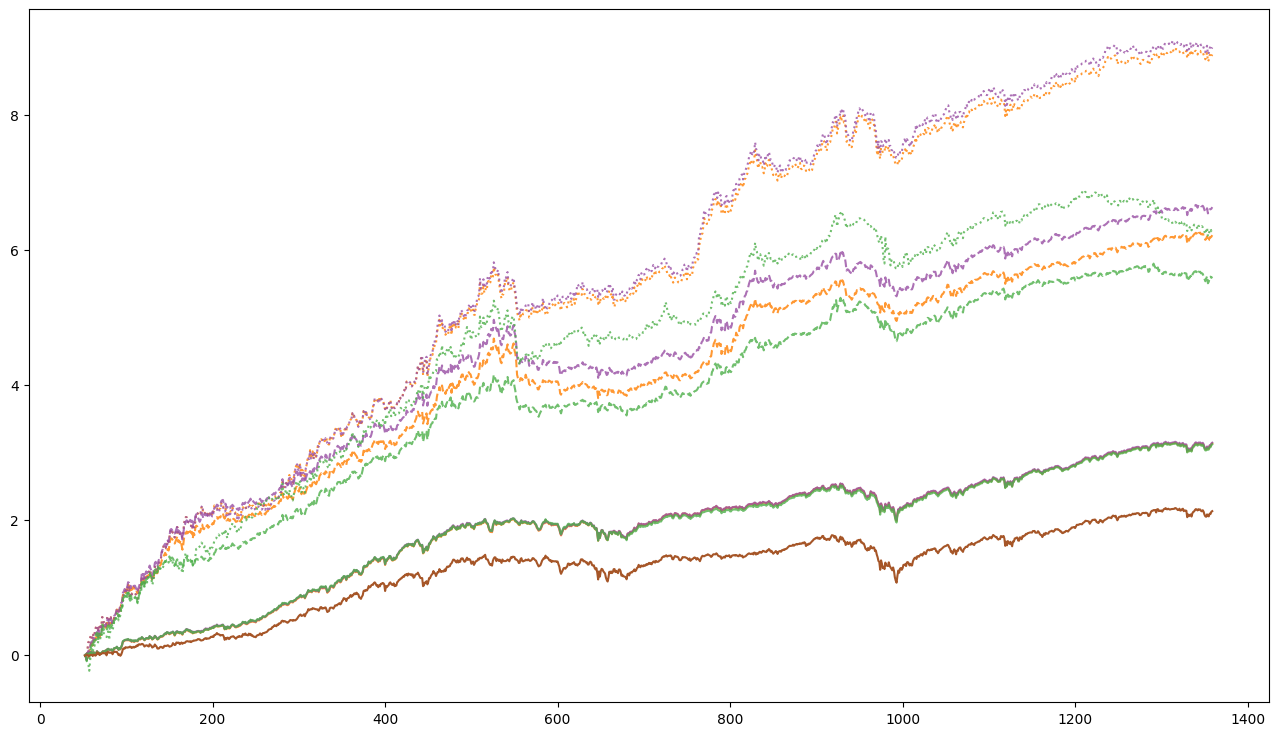

In [17]:
# fig, ax = plt.subplots(figsize=(8,6))
fig, ax = plt.subplots(figsize=(16,9))

num_time_windows = math.floor((len(returns_df) - IN_SAMPLE_TIME_WINDOW) / OUT_OF_SAMPLE_TIME_WINDOW)
num_stocks = int(len(returns_df.columns))
last_week = len(index_returns_df.iloc[IN_SAMPLE_TIME_WINDOW:])
algorithm_labelled = {algorithm: False for algorithm in results_df["algorithm"].unique()}
kl_epsilon_list = [0.00001, 0.001, 1.0]
mmd_epsilon_list = [0.0001, 0.01, 0.2]
line_styles = ["dotted" , "dashed" , "solid"]

# kl_algorithms = ("kl_dro_bas", "kl_pp", "kl_bdro", "kl_empirical")
kl_algorithms = ("kl_dro_bas", "kl_pp", "kl_bdro")

oos_week_numbers = [IN_SAMPLE_TIME_WINDOW + i for i in range(OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows)]
for (algorithm, epsilon), group_df in results_df.groupby(["algorithm", "epsilon"]):
    # assert OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows == len(group_df) * len(group_df["out_of_sample_cost"].values[0])
    is_mmd_experiment = algorithm in ("dro_bas_mmd", "empirical_mmd")
    is_kl_experiment = algorithm in kl_algorithms
    if (is_kl_experiment and epsilon in kl_epsilon_list) or (is_mmd_experiment and epsilon in mmd_epsilon_list):
        cost_list = []
        for i in range(num_replications):
            cost_list += group_df["out_of_sample_cost"].values[i]
        dro_returns = np.array(cost_list)
        # if not algorithm_labelled[algorithm]:
        #     label = AlgorithmName[algorithm].value
        #     algorithm_labelled[algorithm] = True
        # else:
        #     label='_nolegend_'
        if algorithm == "kl_dro_bas":
            label = AlgorithmName[algorithm].value + " ($G +" + str(epsilon) + "$)"
        else:
            label = AlgorithmName[algorithm].value + f" (${epsilon}$)"
        is_robas_experiment = algorithm in ("dro_bas_mmd", "empirical_mmd")
        idx = mmd_epsilon_list.index(epsilon) if is_robas_experiment else kl_epsilon_list.index(epsilon)
        ax.plot(
            oos_week_numbers,
            np.cumsum(dro_returns),
            label=label,
            alpha=0.8,
            color=AlgorithmColor[algorithm].value,
            linestyle=line_styles[idx],
        )
        # ax.text(last_week + IN_SAMPLE_TIME_WINDOW, np.cumsum(dro_returns)[last_week-4], epsilon, color=AlgorithmColor[algorithm].value)
    # if algorithm == "kl_dro_bas" and epsilon in kl_epsilon_list:
    #     ax.text(last_week + IN_SAMPLE_TIME_WINDOW, np.cumsum(dro_returns)[last_week-4]-0.1, np.round(log_partition_constant + epsilon, 5), color=AlgorithmColor[algorithm].value)
    # elif algorithm == "kl_bdro" and  epsilon in kl_epsilon_list:
    #     ax.text(last_week + IN_SAMPLE_TIME_WINDOW, np.cumsum(dro_returns)[last_week-4]-0.1, epsilon, color=AlgorithmColor[algorithm].value)
    # elif algorithm == "dro_bas_mmd" and  epsilon in mmd_epsilon_list:
    #     ax.text(last_week + IN_SAMPLE_TIME_WINDOW, np.cumsum(dro_returns)[last_week-4], epsilon, color=AlgorithmColor[algorithm].value)
    # elif algorithm == "empirical_mmd" and  epsilon in mmd_epsilon_list:
    #     ax.text(last_week + IN_SAMPLE_TIME_WINDOW, np.cumsum(dro_returns)[last_week-4], epsilon, color=AlgorithmColor[algorithm].value)

CB_color_cycle = ['#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']
ax.plot(oos_week_numbers, np.cumsum(index_returns_df.iloc[IN_SAMPLE_TIME_WINDOW:IN_SAMPLE_TIME_WINDOW+OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows].values), label=f"{dgp} Index", color="#a65628")
# for baseline_model in ["CZeSD", "KP_SSD", "L_SSD", "LR_ASSD", "MeanVar", "RMZ_SSD"]:


for algorithm, group_df in cv_df.groupby("algorithm"):
    for i in range(num_replications):
        cost_list += group_df["out_of_sample_cost"].values[i]
    dro_returns = np.array(cost_list)
    label=f"{AlgorithmName[algorithm].value} (CV)"
    ax.plot(
        oos_week_numbers,
        np.cumsum(dro_returns),
        label=label,
        alpha=0.8,
        color=AlgorithmColor[algorithm].value,
        marker="x",
        linestyle="solid",
    )

for i, baseline_model in enumerate(["MeanVar"]):
    baseline_model_label = baseline_model if baseline_model != "MeanVar" else "Markowitz"
    baseline_portfolio_txt = mmc2_dir / "Solutions" / dgp / f"OptPortfolios_{baseline_model}_{dgp}.txt"
    baseline_portfolio = np.loadtxt(baseline_portfolio_txt).T[:num_time_windows, :]
    baseline_returns_txt = mmc2_dir / "Solutions" / dgp / f"OutofSamplePortReturns_{baseline_model}_{dgp}_List.txt" 
    baseline_returns = np.loadtxt(baseline_returns_txt)
    ax.plot(oos_week_numbers, np.cumsum(baseline_returns[:OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows]), label=baseline_model_label, color=CB_color_cycle[i+1])

ax.set_xlabel("Week number")
ax.set_ylabel("Out-of-sample cumulative return")
# ax.set_xlim(2000)
# ax.set_xlim(0, 1520)
# ax.set_ylim(-0.1, 9.5)
ax.vlines(52, -0.3, 4.6, color="black", linestyle=":")
# ax.set_title(dgp + r" cumulative return vs Benchmarks")
# handles, labels = ax.get_legend_handles_labels()
# algorithm_order = [AlgorithmName.kl_dro_bas.value, AlgorithmName.kl_pp.value, AlgorithmName.kl_bdro.value, AlgorithmName.kl_empirical.value]
# order = [list(labels).index(a) for a in algorithm_order]
# ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order])
ax.legend() 
plt.savefig(f"/Users/patrick/Experiments/misdro/2025_01_21_paper_bas_experiments/{experiment_name}_cum_returns_{filter_dgp}.pdf", bbox_inches="tight")
fig.show()

In [ ]:
# is_mmd_experiment = algorithm in ("dro_bas_mmd", "empirical_mmd")
# is_kl_experiment = algorithm in ("kl_dro_bas", "kl_pp", "kl_bdro", "kl_empirical")
# if (is_kl_experiment and epsilon in kl_epsilon_list) or (is_mmd_experiment and epsilon in mmd_epsilon_list):
row_list = []
for (algorithm, epsilon), group_df in results_df.loc[results_df["algorithm"].isin(kl_algorithms)].groupby(["algorithm", "epsilon"]):
    if (algorithm in kl_algorithms and epsilon in kl_epsilon_list) or (is_mmd_experiment and epsilon in mmd_epsilon_list):
        cost_list = []
        for i in range(num_replications):
            cost_list += group_df["out_of_sample_cost"].values[i]
        row_list.append({"cumulative_return": np.sum(cost_list), "epsilon": epsilon, "algorithm": algorithm})
cum_return_df = pd.DataFrame(row_list).set_index(["algorithm", "epsilon"])
cum_return_df = cum_return_df.reindex(pd.MultiIndex.from_arrays([np.repeat(kl_algorithms, len(kl_epsilon_list)), np.tile(kl_epsilon_list, len(kl_algorithms))], names=["algorithm", "epsilon"]))
# solve_time_df.reindex(pd.MultiIndex.from_product(np.repeat(["kl_dro_bas", "kl_pp", "kl_bdro", "kl_empirical"], 3), solve_time_df.index.get_level_values("num_total_samples"), names=['algorithm', 'num_total_samples']))
print(cum_return_df.unstack(level="algorithm").to_latex())
# cum_return_df

\begin{tabular}{lrrr}
\toprule
 & \multicolumn{3}{r}{cumulative_return} \\
algorithm & kl_bdro & kl_dro_bas & kl_pp \\
epsilon &  &  &  \\
\midrule
0.000010 & 8.891674 & 8.996575 & 6.301317 \\
0.001000 & 6.215896 & 6.631364 & 5.603279 \\
1.000000 & 3.130615 & 3.141029 & 3.116720 \\
\bottomrule
\end{tabular}



In [ ]:
solve_time_df = get_agg_df(results_df, ["algorithm"])[["mean_solve_time", "std_solve_time", "mean_sample_time", "std_sample_time"]]

decimal_places = 2
solve_time_df["str_solve_time"] = solve_time_df[["mean_solve_time", "std_solve_time"]].apply(
    lambda x: "{:.2f}".format(np.round(x["mean_solve_time"], decimal_places)) + " (" + "{:.2f}".format(np.round(x["std_solve_time"], decimal_places)) + ")", axis=1
)
solve_time_df["str_sample_time"] = solve_time_df[["mean_sample_time", "std_sample_time"]].apply(
    lambda x: "{:.2f}".format(np.round(1000 * x["mean_sample_time"], decimal_places)) + " (" + "{:.2f}".format(np.round(1000 * x["std_sample_time"], decimal_places)) + ")", axis=1
)
solve_time_df = solve_time_df.reindex(["kl_dro_bas", "kl_pp", "kl_bdro", "kl_empirical"])
solve_time_df.index = solve_time_df.index.map(lambda x: AlgorithmName[x].value)
print(solve_time_df[["str_solve_time", "str_sample_time"]].to_latex())

\begin{tabular}{lll}
\toprule
 & str_solve_time & str_sample_time \\
algorithm &  &  \\
\midrule
DRO-BAS$_{PE}$ & 0.01 (0.01) & 0.35 (0.30) \\
DRO-BAS$_{PP}$ & 1.34 (0.22) & 3.48 (0.91) \\
BDRO & 4.47 (0.62) & 44.45 (3.11) \\
Empirical KL & 0.03 (0.00) & 0.02 (0.00) \\
\bottomrule
\end{tabular}



/Users/patrick/Projects/mis-dro-code/mis_dro/plot.py:207: FutureWarning: The provided callable <function mean at 0x10daca0c0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/Users/patrick/Projects/mis-dro-code/mis_dro/plot.py:207: FutureWarning: The provided callable <function std at 0x10daca200> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(


In [ ]:
# bas_returns = []
# bdro_returns = []
# filter_epsilon = 0.1
# for (algorithm, epsilon), group_df in gb:
#     # dro_returns = group_df[week_cols].values.flatten()
#     if algorithm == "kl_dro_bas" and epsilon == filter_epsilon:
#         assert OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows == len(group_df) * len(group_df["out_of_sample_cost"].values[0])
#         for i in range(num_replications):
#             bas_returns += group_df["out_of_sample_cost"].values[i]
#     if algorithm == "kl_bdro" and epsilon == filter_epsilon:
#         assert OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows == len(group_df) * len(group_df["out_of_sample_cost"].values[0])
#         for i in range(num_replications):
#             bdro_returns += group_df["out_of_sample_cost"].values[i]
# plt.hist(bas_returns, bins=50, label="BAS", alpha=0.5)
# plt.hist(bdro_returns, bins=50, label="BDRO", alpha=0.5)
# plt.legend()

NameError: name 'gb' is not defined

In [ ]:
# from mis_dro.dataset import portfolio_dataset

# # training_time_window_id = 75
# training_time_window_id = 79
# out_of_sample_time_window = IN_SAMPLE_TIME_WINDOW
# data, data_eval = portfolio_dataset("DowJones-crash", training_time_window_id, mmc2_dir, out_of_sample_time_window=out_of_sample_time_window)
# dim = data.shape[1]
# sol = np.ones(dim) / float(dim)
# data.shape, data_eval.shape

((52, 28), (52, 28))

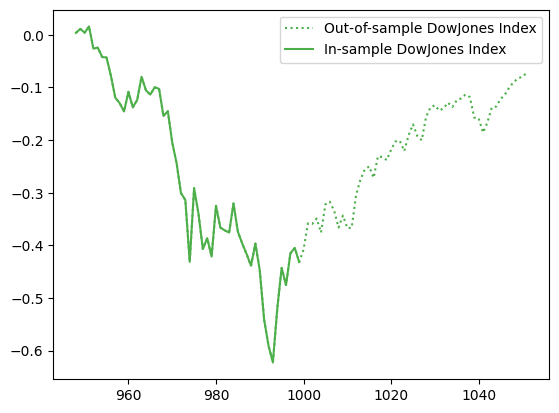

In [ ]:
start_training_week = training_time_window_id * OUT_OF_SAMPLE_TIME_WINDOW # inclusive
end_training_week = start_training_week + IN_SAMPLE_TIME_WINDOW # not inclusive
test_start = end_training_week
test_end = test_start + out_of_sample_time_window
total_training_returns = (data @ sol).sum()

plt.plot(oos_week_numbers[start_training_week- IN_SAMPLE_TIME_WINDOW:test_end - IN_SAMPLE_TIME_WINDOW], np.cumsum(index_returns_df.iloc[start_training_week:test_end].values), label=f"Out-of-sample {dgp} Index", color=CB_color_cycle[0], linestyle="dotted")
plt.plot(oos_week_numbers[start_training_week- IN_SAMPLE_TIME_WINDOW:test_start - IN_SAMPLE_TIME_WINDOW], np.cumsum(index_returns_df.iloc[start_training_week:test_start].values), label=f"In-sample {dgp} Index", color=CB_color_cycle[0])

# plt.plot(oos_week_numbers[start_training_week - IN_SAMPLE_TIME_WINDOW:end_training_week - IN_SAMPLE_TIME_WINDOW], (data @ sol).cumsum())
# plt.plot(oos_week_numbers[test_start - IN_SAMPLE_TIME_WINDOW:test_end - IN_SAMPLE_TIME_WINDOW], (data_eval @ sol).cumsum())
plt.legend()
